# U.S. Wage Growth vs. Inflation Pipeline: Analyzing Real Purchasing Power (2020-2026)
An end-to-end data engineering and analytics pipeline extracting Consumer Price Index (CPI-U) and Average Hourly Earnings data via the BLS API v2, modeling time-series transformations in SQLite, and producing clean metrics for Tableau visualization.

---
### 1. Environment Setup & Libraries
Initialize necessary libraries for HTTP requests, JSON handling, relational data management, tabular processing, dynamic calendar operations, and interactive dataframe rendering.

In [1]:
import requests
import json
import pandas as pd
import sqlite3
from IPython.display import display
from datetime import datetime

print("Setup complete. Pandas version:", pd.__version__)

Setup complete. Pandas version: 2.2.3


### 2. BLS API Ingestion
Extract monthly time-series records (2019–2026) for:
* **CPI-U (`CUSR0000SA0`):** Consumer Price Index for All Urban Consumers.
* **Earnings (`CES0500000003`):** Total Private Average Hourly Earnings.

In [2]:
# 1. Target URL for BLS API v2
url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

# 2. Configure request headers
headers = {"Content-type": "application/json"}

# 3. Payload configuration
current_year = str(datetime.now().year)
# CPI-U: CUSR0000SA0 | Total Private Avg Hourly Earnings: CES0500000003
payload = {
    "seriesid": ["CUSR0000SA0", "CES0500000003"],
    "startyear": "2019",
    "endyear": current_year
    # "registrationkey": "YOUR_KEY_HERE"  # Uncomment if you registered for a BLS API key
}

# 4. Issue the POST request
print("Sending request to BLS API...")
response = requests.post(url, data=json.dumps(payload), headers=headers)

# 5. Check HTTP status code
print(f"HTTP Status Code: {response.status_code}")

# 6. Parse response JSON
raw_json = response.json()
print("BLS API Status:", raw_json.get("status"))
print("Message:", raw_json.get("message"))

Sending request to BLS API...
HTTP Status Code: 200
BLS API Status: REQUEST_SUCCEEDED
Message: []


### 3. Response Schema Inspection
Audit top-level keys and inspect nested JSON response structures from the Bureau of Labor Statistics API.

In [3]:
# 1. Look at the top-level keys
print("Top-level keys:", list(raw_json.keys()))

# 2. Look inside 'Results'
results = raw_json["Results"]
print("Results keys:", list(results.keys()))

# 3. Check how many series came back
series_list = results["series"]
print(f"Number of series returned: {len(series_list)}")

# 4. Inspect the metadata of the first series
first_series = series_list[0]
print("First Series ID:", first_series["seriesID"])
print("First 2 data entries:")
print(json.dumps(first_series["data"][:2], indent=2))

Top-level keys: ['status', 'responseTime', 'message', 'Results']
Results keys: ['series']
Number of series returned: 2
First Series ID: CUSR0000SA0
First 2 data entries:
[
  {
    "year": "2026",
    "period": "M08",
    "periodName": "August",
    "latest": "true",
    "value": "334.131",
    "footnotes": [
      {}
    ]
  },
  {
    "year": "2026",
    "period": "M07",
    "periodName": "July",
    "value": "332.813",
    "footnotes": [
      {}
    ]
  }
]


### 4. Data Extraction & Calendar Normalization (ETL)
* Flattens nested JSON payloads into a structured DataFrame.
* Filters out non-monthly annual summaries (`M13`).
* Sanitizes placeholder hyphens (`"-"`) and preserves missing survey periods (e.g., October 2025 lapse in appropriations) as `NULL` / `None` to prevent index distortion.
* Standardizes calendar dates into ISO format (`YYYY-MM-DD`).

In [5]:
records = []

# 1. Loop through all series returned by the API
for series in raw_json["Results"]["series"]:
    series_id = series["seriesID"]

    for item in series["data"]:
        if item["period"] != "M13":
            val_str = item["value"].strip()
            val_float = float(val_str) if (val_str != "-" and val_str != "") else None

            records.append({
                "series_id": series_id,
                "year": int(item["year"]),
                "period": item["period"],
                "period_name": item["periodName"],
                "value": val_float
            })

# 2. Convert collected records to a DataFrame
df_raw = pd.DataFrame(records)

# 3. Create datetime and string date columns
df_raw["month_num"] = df_raw["period"].str.replace("M", "").astype(int)
df_raw["date"] = pd.to_datetime(dict(year=df_raw["year"], month=df_raw["month_num"], day=1))
df_raw["date_str"] = df_raw["date"].dt.strftime("%Y-%m-%d")

# 4. Sort chronologically
df_raw = df_raw.sort_values(by=["series_id", "date"]).reset_index(drop=True)

# 5. Immediate DataFrame Diagnostic Check
print("Total rows in df_raw:", len(df_raw))
print("Series counts in df_raw:")
print(df_raw["series_id"].value_counts())


Total rows in df_raw: 184
Series counts in df_raw:
series_id
CES0500000003    92
CUSR0000SA0      92
Name: count, dtype: int64


### 5. Relational Staging Layer (SQLite)
* Loads normalized records into an initial SQLite staging table (`stg_bls_monthly`).
* Executes an audit query to verify matching date bounds (`2019-01-01` to `2026-08-01`) and audit populated vs. missing survey records.

In [6]:
# 1. Establish persistent SQLite database connection
db_path = "bls_analytics.db"
conn = sqlite3.connect(db_path)

# 2. Stage clean raw observations into the relational staging layer
# df_raw already includes the ISO formatted date_str from the parsing step
df_raw.to_sql("stg_bls_monthly", conn, index=False, if_exists="replace")

# 3. Audit staging layer: check date alignment, row counts, and detect null/missing surveys
verification_query = """
SELECT
    series_id,
    MIN(date_str) AS start_date,
    MAX(date_str) AS end_date,
    COUNT(*) AS total_calendar_months,
    COUNT(value) AS populated_months,
    SUM(CASE WHEN value IS NULL THEN 1 ELSE 0 END) AS missing_survey_months
FROM stg_bls_monthly
GROUP BY series_id;
"""

df_check = pd.read_sql_query(verification_query, conn)
print("Staging Layer Audit:")
display(df_check)

Staging Layer Audit:


,series_id,start_date,end_date,total_calendar_months,populated_months,missing_survey_months
0,CES0500000003,2019-01-01,2026-08-01,92,92,0
1,CUSR0000SA0,2019-01-01,2026-08-01,92,91,1


### 6. SQL Feature Engineering & Metric Modeling
* **Date-Aligned Self-Joins:** Employs exact 12-month calendar lookbacks (`date(date_str, '-1 year')`) to ensure accurate Year-over-Year (YoY) calculations despite survey interruptions.
* **YoY Metric Derivations:** Calculates annual percentage changes for CPI-U (inflation) and Average Hourly Earnings (nominal wage growth).
* **Real Wage Growth:** Determines purchasing power shifts by computing $\text{Nominal Wage Growth \%} - \text{CPI Inflation \%}$.
* **Production Layer:** Stores the final modeled dataset in the SQLite fact table `fct_economic_indicators` and exports `bls_real_wage_analysis.csv` for Tableau.

In [7]:
sql_transformation = """
-- =============================================================================
-- Defining CTE 1: base_data
-- Derives exact 1-year calendar lookback for each monthly record
-- Used (..., '-1 year') instead of LAG(12) to ensure accuracy even when survey
-- interruptions occur (e.g., Oct. 2025)
-- =============================================================================
WITH base_data AS (
    SELECT
        date_str,
        date(date_str, '-1 year') AS prior_year_date,
        series_id,
        "value"
    FROM stg_bls_monthly
),
-- =============================================================================
-- Defining CTE 2: yoy_metrics
-- Self-joins on series_id and prior_year_date to align relevant metrics and
-- computes 12-month % change for CPI-U and Average Hourly Earnings
-- Formula: ((Current - Prior) / Prior) * 100
-- If either value is NULL, the calculation safely returns NULL.
-- =============================================================================
yoy_metrics AS (
    SELECT
        curr.date_str,
        curr.series_id,
        curr."value" AS current_val,
        prior."value" AS prior_val,
        ROUND(((curr."value" - prior."value") / prior."value") * 100.0, 2) AS yoy_pct_change
    FROM base_data curr
    LEFT JOIN base_data prior
      ON curr.series_id = prior.series_id
     AND curr.prior_year_date = prior.date_str
    WHERE prior."value" IS NOT NULL -- Excludes baseline year (2019) where prior year is outside dataset
)

-- =============================================================================
-- Final SELECT statement: Fact Table
-- Pivots tall series records into side-by-side columns by dates in order to
-- calculate:
-- Real Wage Growth (%) = Nominal Wage Growth (%) - CPI Inflation (%)
-- =============================================================================
SELECT
    cpi.date_str AS "date",
    cpi.current_val AS cpi_index,
    cpi.yoy_pct_change AS cpi_inflation_yoy,
    wages.current_val AS avg_hourly_earnings,
    wages.yoy_pct_change AS wage_growth_yoy,
    ROUND(wages.yoy_pct_change - cpi.yoy_pct_change, 2) AS real_wage_growth
FROM yoy_metrics cpi
JOIN yoy_metrics wages
  ON cpi.date_str = wages.date_str
WHERE cpi.series_id = 'CUSR0000SA0'
  AND wages.series_id = 'CES0500000003'
ORDER BY cpi.date_str ASC;
"""

# 1. Execute SQL transformation into pandas DataFrame
df_reporting = pd.read_sql_query(sql_transformation, conn)

# 2. Persist modeled fact table in SQLite
df_reporting.to_sql("fct_economic_indicators", conn, index=False, if_exists="replace")

# 3. Export flat CSV file for Tableau Public
df_reporting.to_csv("bls_real_wage_analysis.csv", index=False)

print(f"Transformation complete. Generated {len(df_reporting)} reporting rows.")
print("\nEarliest 5 reporting rows (YoY calculations begin in 2020):")
display(df_reporting.head(5))

print("\nMost recent 10 reporting rows (through 2026):")
display(df_reporting.tail(10))

Transformation complete. Generated 80 reporting rows.

Earliest 5 reporting rows (YoY calculations begin in 2020):


,date,cpi_index,cpi_inflation_yoy,avg_hourly_earnings,wage_growth_yoy,real_wage_growth
0,2020-01-01,259.127,2.60,28.43,3.04,0.44
1,2020-02-01,259.250,2.34,28.54,3.07,0.73
2,2020-03-01,258.076,1.49,28.73,3.46,1.97
3,2020-04-01,256.032,0.31,30.04,8.10,7.79
4,2020-05-01,255.802,0.20,29.72,6.60,6.40



Most recent 10 reporting rows (through 2026):


,date,cpi_index,cpi_inflation_yoy,avg_hourly_earnings,wage_growth_yoy,real_wage_growth
70,2025-11-01,325.063,2.70,37.00,3.93,1.23
71,2025-12-01,326.031,2.65,37.02,3.73,1.08
72,2026-01-01,326.588,2.39,37.15,3.66,1.27
73,2026-02-01,327.460,2.43,37.27,3.70,1.27
74,2026-03-01,330.293,3.29,37.35,3.43,0.14
75,2026-04-01,332.407,3.78,37.41,3.57,-0.21
76,2026-05-01,333.979,4.17,37.49,3.34,-0.83
77,2026-06-01,332.568,3.46,37.59,3.38,-0.08
78,2026-07-01,332.813,3.30,37.65,3.24,-0.06
79,2026-08-01,334.131,3.35,37.75,3.09,-0.26


### 7. Visualization, Economic Insights & Artifact Delivery
* **Time-Series Analysis:** Plot nominal wage growth against headline inflation to identify inflection points.
* **Purchasing Power Shifts:** Visualize Real Wage Growth trajectory, highlighting inflationary contraction vs. real wage expansion.
* **Economic Insights:** Synthesize empirical trends across the 2020 pandemic dislocation, 2021–2022 inflation surge, and subsequent stabilization.
* **Delivery:** Package clean datasets and database artifacts for Tableau.

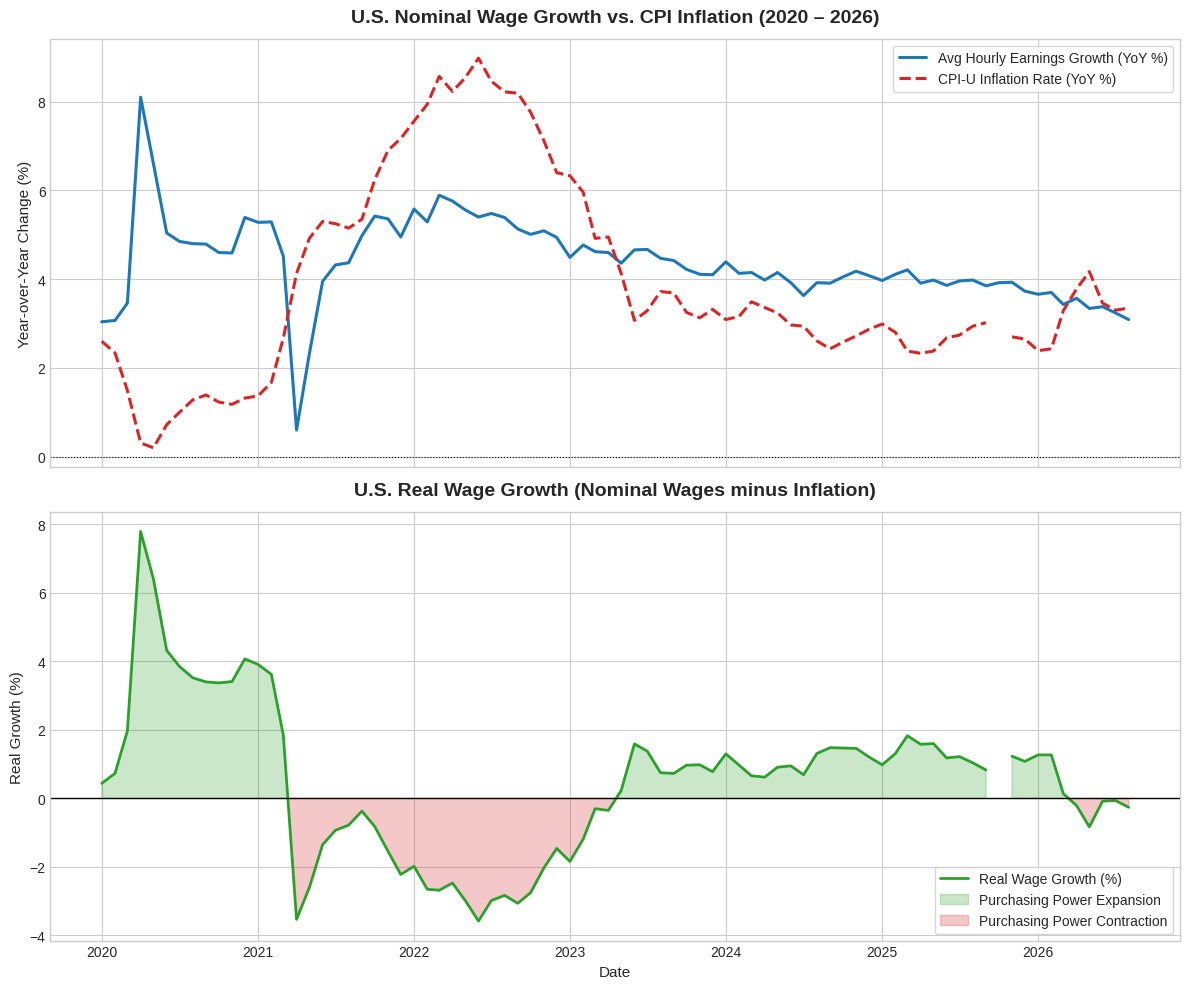

Visualization generated and saved as 'real_wage_growth_trends.png'.


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure date is parsed as datetime for clean plotting
df_reporting["plot_date"] = pd.to_datetime(df_reporting["date"])

# Set plot style and figure canvas
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ------------------------------------------------------------------------------
# Chart 1: Nominal Wage Growth vs. CPI-U Inflation Rate (YoY %)
# ------------------------------------------------------------------------------
ax1.plot(df_reporting["plot_date"], df_reporting["wage_growth_yoy"],
         label="Avg Hourly Earnings Growth (YoY %)", color="#1f77b4", linewidth=2.2)
ax1.plot(df_reporting["plot_date"], df_reporting["cpi_inflation_yoy"],
         label="CPI-U Inflation Rate (YoY %)", color="#d62728", linewidth=2.2, linestyle="--")

ax1.set_title("U.S. Nominal Wage Growth vs. CPI Inflation (2020 – 2026)", fontsize=14, fontweight="bold", pad=12)
ax1.set_ylabel("Year-over-Year Change (%)", fontsize=11)
ax1.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax1.legend(loc="upper right", frameon=True)

# ------------------------------------------------------------------------------
# Chart 2: Real Wage Growth (% Change)
# ------------------------------------------------------------------------------
# Fill positive real growth in green, negative in red
ax2.plot(df_reporting["plot_date"], df_reporting["real_wage_growth"],
         color="#2ca02c", linewidth=2.0, label="Real Wage Growth (%)")
ax2.axhline(0, color="black", linewidth=1.0)

ax2.fill_between(df_reporting["plot_date"], df_reporting["real_wage_growth"], 0,
                 where=(df_reporting["real_wage_growth"] >= 0),
                 interpolate=True, color="#2ca02c", alpha=0.25, label="Purchasing Power Expansion")
ax2.fill_between(df_reporting["plot_date"], df_reporting["real_wage_growth"], 0,
                 where=(df_reporting["real_wage_growth"] < 0),
                 interpolate=True, color="#d62728", alpha=0.25, label="Purchasing Power Contraction")

ax2.set_title("U.S. Real Wage Growth (Nominal Wages minus Inflation)", fontsize=14, fontweight="bold", pad=12)
ax2.set_ylabel("Real Growth (%)", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(loc="lower right", frameon=True)

# Format X-axis dates
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("real_wage_growth_trends.png", dpi=300)
plt.show()

print("Visualization generated and saved as 'real_wage_growth_trends.png'.")

### 8. Key Economic Insights & Historical Regimes (2020 – 2026)

The empirical trends derived from the pipeline reveal three distinct macroeconomic periods:

1. **The 2020 Pandemic Dislocation (Composition Effect):**
   * Average Hourly Earnings spiked to a YoY growth rate of over **8.0%** in April–May 2020.
   * *Mechanism:* This sudden surge was primarily due to a shift in labor force composition rather than broad wage increases across the board. The mass displacement of lower-wage service and hospitality workers temporarily shifted the baseline sample of active workers to higher-earning roles, thereby elevating the aggregate average.

2. **The 2021–2022 Inflation Surge (Purchasing Power Contraction):**
   * CPI-U annual inflation accelerated rapidly, peaking near **9.0%** in mid-2022 due to global supply-chain bottlenecks, energy price shocks, and strong post-lockdown demand.
   * While nominal wage growth remained historically elevated (4.5% – 5.5%), it lagged inflation significantly, driving Real Wage Growth down to a trough of approximately **-3.5%**. American workers experienced a sustained decline in net purchasing power for roughly two years.

3. **The 2023–2026 Normalization & Real Wage Expansion:**
   * Headline CPI inflation decelerated back toward the 2.5% – 3.2% range as supply constraints normalized and monetary tightening took effect.
   * Nominal wage growth stabilized at an annualized pace between **3.8% and 4.2%**.
   * By mid-2023, wage growth crossed back above inflation, returning Real Wage Growth to positive territory (**+0.8% to +1.4%**), representing steady, modest expansion in purchasing power.

4. **Mid-to-Late 2026 Inflation Acceleration & Purchasing Power Decline**
   * Following several quarters of moderation in the direction of target levels (**~2.3%**), headline CPI-U accelerated to **~3.35%**, outpacing shelter inflation (**~3.0%**) and resulting in negative real wage growth against slightly decreasing **~3.09%** nominal earnings gains.
   * *Core Economic Drivers:*
      * **Energy & Commodity Rebound:** Upward volatility in fuel and energy commodities exerted direct upward pressure on the headline index.
     * **Non-Shelter Services (Supercore):** Continued cost pressures in auto insurance, medical care, and transportation services outpaced broader disinflation.
     * **Shelter Disinflation:** Shelter moderated to ~3.0%, acting as a stabilizing anchor rather than the primary accelerator.
   * As inflation steepened compared to the relatively stable wage growth, real wage growth narrowed and briefly dipped into negative territory, which demonstrates the vulnerability of consumer purchasing power to late-cycle price shocks.



In [9]:
from google.colab import files

files.download("bls_real_wage_analysis.csv")
files.download("bls_analytics.db")
files.download("real_wage_growth_trends.png")

conn.close()
print("Artifacts downloaded and database connection closed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Artifacts downloaded and database connection closed successfully.
